# 🔵 TẦNG 2 — DIAGNOSTIC ANALYTICS
## *"Why did it happen?"* — Tại sao lại như vậy?

> **Mục tiêu:** Phân tích nguyên nhân chênh lệch lương — so sánh nhóm & kiểm định thống kê.  
> **Trả lời:**  
> - ❓ Câu hỏi 3: Có sự chênh lệch lương giữa các nhóm lập trình viên không?

---

## ⚙️ PHẦN 0: IMPORT & CHUẨN BỊ DỮ LIỆU

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('husl', 12)
BLUE  = '#2563EB'
RED   = '#EF4444'
GREEN = '#10B981'
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [10]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# Đọc dữ liệu
# ─────────────────────────────────────────────────────────────
df = pd.read_csv('salary_data.csv')

# chuẩn hoá tên cột
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# xoá duplicate
df = df.drop_duplicates()

# ─────────────────────────────────────────────────────────────
# Tự động tìm cột lương
# ─────────────────────────────────────────────────────────────
sal_kw = [
    'salary',
    'pay',
    'comp',
    'wage',
    'income',
    'ctc',
    'annual'
]

SAL_COL = next(
    (
        c for c in df.columns
        if any(k in c for k in sal_kw)
    ),
    None
)

if SAL_COL is None:
    raise ValueError(
        '❌ Không tìm thấy cột lương'
    )

print(
    f'✅ Cột lương tìm được: {SAL_COL}'
)

# ─────────────────────────────────────────────────────────────
# Làm sạch cột lương
# ─────────────────────────────────────────────────────────────

# ép string
df[SAL_COL] = df[SAL_COL].astype(str)

# lowercase
df[SAL_COL] = df[SAL_COL].str.lower()

# xử lý 120k -> 120000
df[SAL_COL] = df[SAL_COL].str.replace(
    r'(\d+(?:\.\d+)?)k',
    lambda m: str(float(m.group(1)) * 1000),
    regex=True
)

# xoá ký tự đặc biệt
df[SAL_COL] = (
    df[SAL_COL]
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(r'[^0-9.]', '', regex=True)
    .str.strip()
)

# convert numeric
df[SAL_COL] = pd.to_numeric(
    df[SAL_COL],
    errors='coerce'
)

# xoá NaN
df = df.dropna(
    subset=[SAL_COL]
)

# ép float
df[SAL_COL] = df[SAL_COL].astype(float)

# ─────────────────────────────────────────────────────────────
# Kiểm tra kiểu dữ liệu
# ─────────────────────────────────────────────────────────────
print('\n📌 Kiểu dữ liệu salary:')
print(df[SAL_COL].dtype)

print('\n📌 Kiểu object thực tế:')
print(
    df[SAL_COL]
    .apply(type)
    .value_counts()
)

# ─────────────────────────────────────────────────────────────
# Loại outlier
# ─────────────────────────────────────────────────────────────
q01 = df[SAL_COL].quantile(0.01)
q99 = df[SAL_COL].quantile(0.99)

df = df[
    (df[SAL_COL] >= q01) &
    (df[SAL_COL] <= q99)
]

# ─────────────────────────────────────────────────────────────
# Fill missing values
# ─────────────────────────────────────────────────────────────
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[col]):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

# ─────────────────────────────────────────────────────────────
# Salary variable
# ─────────────────────────────────────────────────────────────
sal = df[SAL_COL]

# ─────────────────────────────────────────────────────────────
# TỰ ĐỘNG TÌM CÁC CỘT PHÂN TÍCH
# ─────────────────────────────────────────────────────────────

def find_col(keywords):

    return next(
        (
            c for c in df.columns
            if any(k in c for k in keywords)
        ),
        None
    )

# Job Role
ROLE_COL = find_col([
    'job_role',
    'job_roles',
    'role',
    'position',
    'title'
])

# Employment Status
STATUS_COL = find_col([
    'employment_status',
    'employment',
    'status',
    'job_type',
    'work_type'
])

# Company Rating
RATING_COL = find_col([
    'rating',
    'company_rating',
    'score'
])

# Quốc gia / địa lý
LOCATION_COL = find_col([
    'country',
    'location',
    'region',
    'city',
    'state'
])

# Company
COMPANY_COL = find_col([
    'company',
    'company_name',
    'employer',
    'organization'
])

# ─────────────────────────────────────────────────────────────
# Thông tin dữ liệu
# ─────────────────────────────────────────────────────────────
print('\n' + '='*65)

print(
    f'✅ Dữ liệu sau xử lý: {df.shape[0]:,} dòng'
)

print(
    f'✅ Salary range: '
    f'${sal.min():,.0f} → ${sal.max():,.0f}'
)

print('\n📌 Cột phân tích tìm được:')

print(f'   Job Role         : {ROLE_COL}')
print(f'   Employment Status: {STATUS_COL}')
print(f'   Company Rating   : {RATING_COL}')
print(f'   Location         : {LOCATION_COL}')
print(f'   Company Name     : {COMPANY_COL}')

print('\n📌 Các cột hiện có trong dataset:')

for i, c in enumerate(df.columns, 1):

    print(f'   {i:>2}. {c}')

print('\n⚠️ Nếu phát hiện sai cột:')
print('Ví dụ:')
print('ROLE_COL = "job_roles"')
print('STATUS_COL = "employment_status"')

print('='*65)

✅ Cột lương tìm được: company_name

📌 Kiểu dữ liệu salary:
float64

📌 Kiểu object thực tế:
company_name
<class 'float'>    412
Name: count, dtype: int64

✅ Dữ liệu sau xử lý: 406 dòng
✅ Salary range: $1 → $17,544

📌 Cột phân tích tìm được:
   Job Role         : job_title
   Employment Status: employment_status
   Company Rating   : rating
   Location         : location
   Company Name     : company_name

📌 Các cột hiện có trong dataset:
    1. rating
    2. company_name
    3. job_title
    4. salary
    5. salaries_reported
    6. location
    7. employment_status
    8. job_roles

⚠️ Nếu phát hiện sai cột:
Ví dụ:
ROLE_COL = "job_roles"
STATUS_COL = "employment_status"


---
## 📌 PHẦN 1: CHÊNH LỆCH LƯƠNG THEO EMPLOYMENT STATUS


📊 Salary theo Employment Status:

employment_status  count   mean  median     std
       Contractor      6  44.67     4.0   99.16
           Intern     39 145.77     8.0  499.00
        Full Time    361 170.25     5.0 1109.25


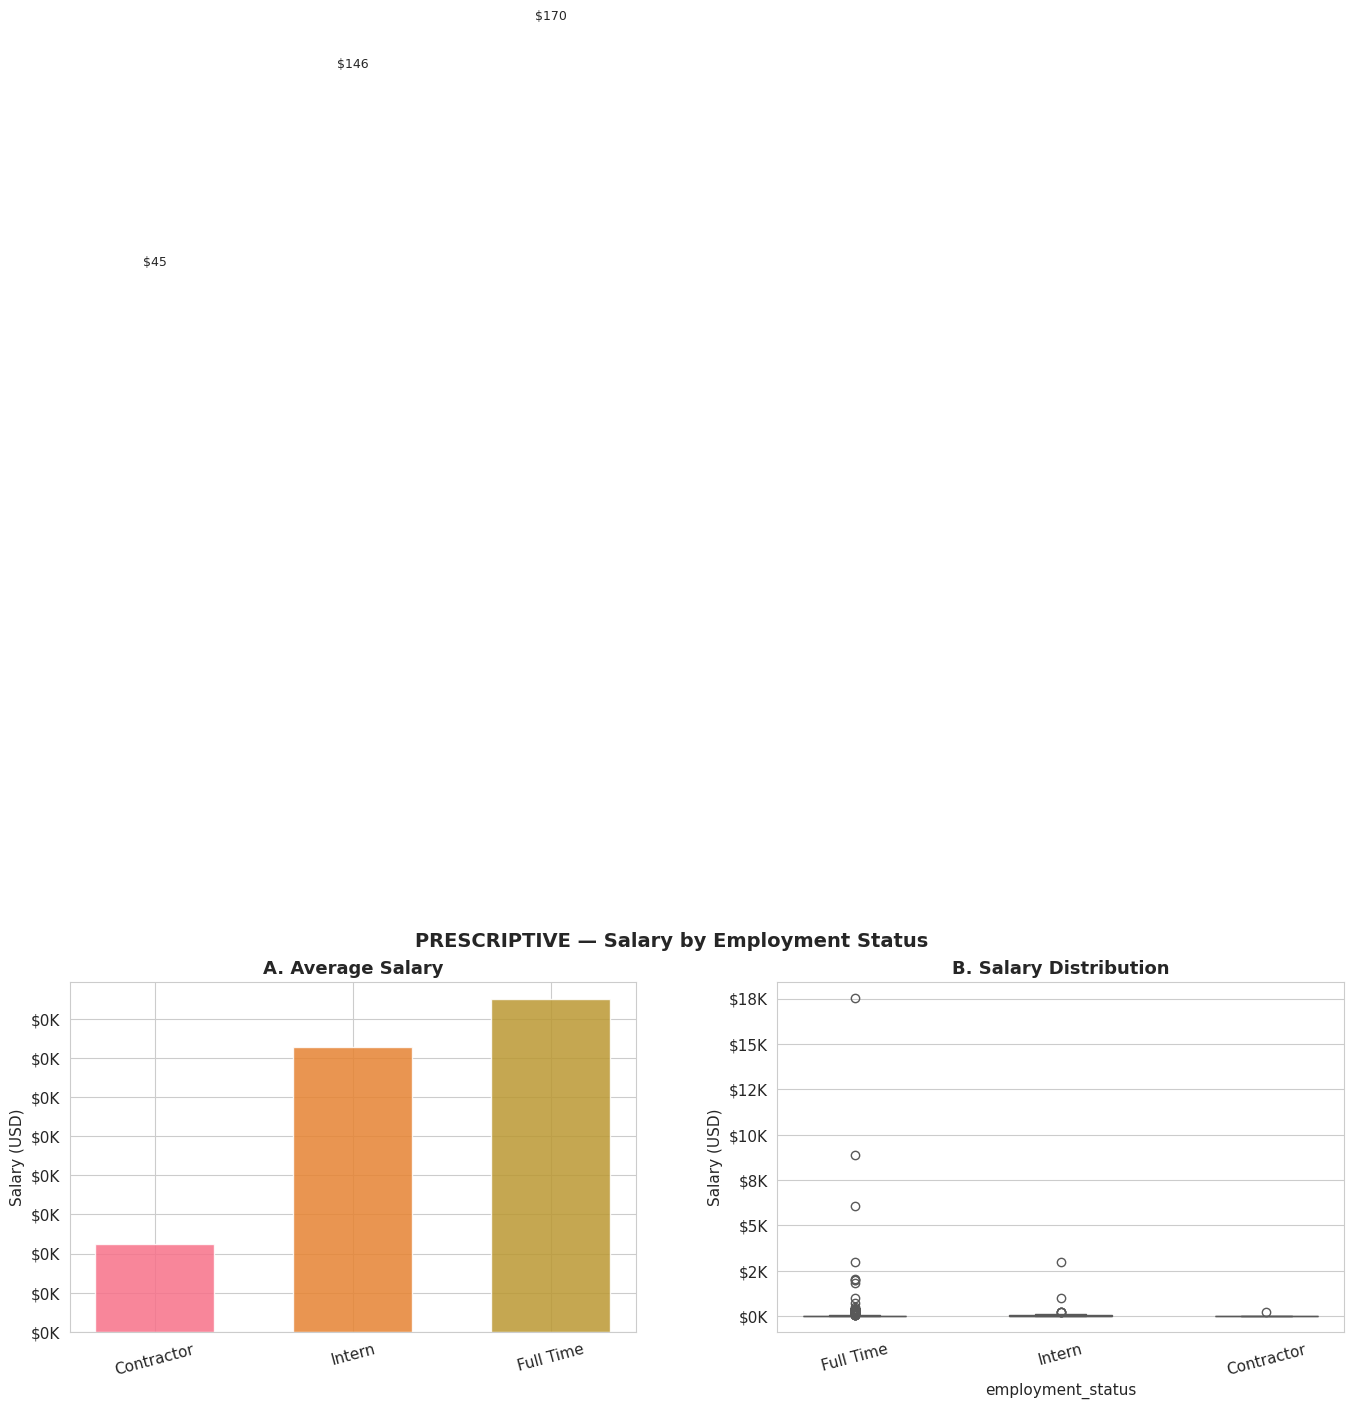


💾 Lưu: pres_02_salary_by_employment_status.png


In [16]:
# ─────────────────────────────────────────────────────────────
# PRESCRIPTIVE — Salary by Employment Status
# ─────────────────────────────────────────────────────────────

STATUS_COL = 'employment_status'

if STATUS_COL in df.columns:

    # ========================================================
    # Statistics
    # ========================================================
    status_stats = (
        df
        .groupby(STATUS_COL)[SAL_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .reset_index()
        .sort_values('mean')
    )

    status_stats['std'] = (
        status_stats['std']
        .fillna(0)
    )

    print('📊 Salary theo Employment Status:\n')

    print(
        status_stats
        .round(2)
        .to_string(index=False)
    )

    # ========================================================
    # Figure
    # ========================================================
    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5)
    )

    fig.suptitle(
        'PRESCRIPTIVE — Salary by Employment Status',
        fontsize=14,
        fontweight='bold',
        y=0.98
    )

    # ========================================================
    # A. BAR CHART
    # ========================================================
    ax = axes[0]

    bars = ax.bar(
        status_stats[STATUS_COL],
        status_stats['mean'],
        color=PALETTE[:len(status_stats)],
        edgecolor='white',
        alpha=0.85,
        width=0.6
    )

    # labels
    for bar, val in zip(bars, status_stats['mean']):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 500,
            f'${val:,.0f}',
            ha='center',
            fontsize=9
        )

    ax.set_title(
        'A. Average Salary'
    )

    ax.set_ylabel(
        'Salary (USD)'
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    ax.tick_params(
        axis='x',
        rotation=15
    )

    # bỏ khoảng trắng dư
    ax.margins(x=0.05)

    # ========================================================
    # B. BOXPLOT
    # ========================================================
    ax = axes[1]

    sns.boxplot(
        data=df,
        x=STATUS_COL,
        y=SAL_COL,
        palette='Set2',
        ax=ax,
        width=0.5
    )

    ax.set_title(
        'B. Salary Distribution'
    )

    ax.set_ylabel(
        'Salary (USD)'
    )

    ax.tick_params(
        axis='x',
        rotation=15
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    ax.margins(x=0.05)

    # ========================================================
    # FIX KHOẢNG TRẮNG THỪA
    # ========================================================
    plt.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.88,
        bottom=0.18,
        wspace=0.25
    )

    # ========================================================
    # SAVE
    # ========================================================
    plt.savefig(
        'pres_02_salary_by_employment_status.png',
        dpi=150,
        bbox_inches='tight',
        pad_inches=0.2
    )

    plt.show()

    print(
        '\n💾 Lưu: pres_02_salary_by_employment_status.png'
    )

else:

    print(
        '❌ Không tìm thấy cột employment_status'
    )

---
## 📌 PHẦN 2: CHÊNH LỆCH LƯƠNG THEO COMPANY RATING


📊 Thống kê Rating:

count    406.00
mean       3.99
std        0.58
min        1.00
25%        3.80
50%        4.00
75%        4.30
max        5.00
Name: rating, dtype: float64

📈 Correlation giữa Rating và Salary: -0.0009


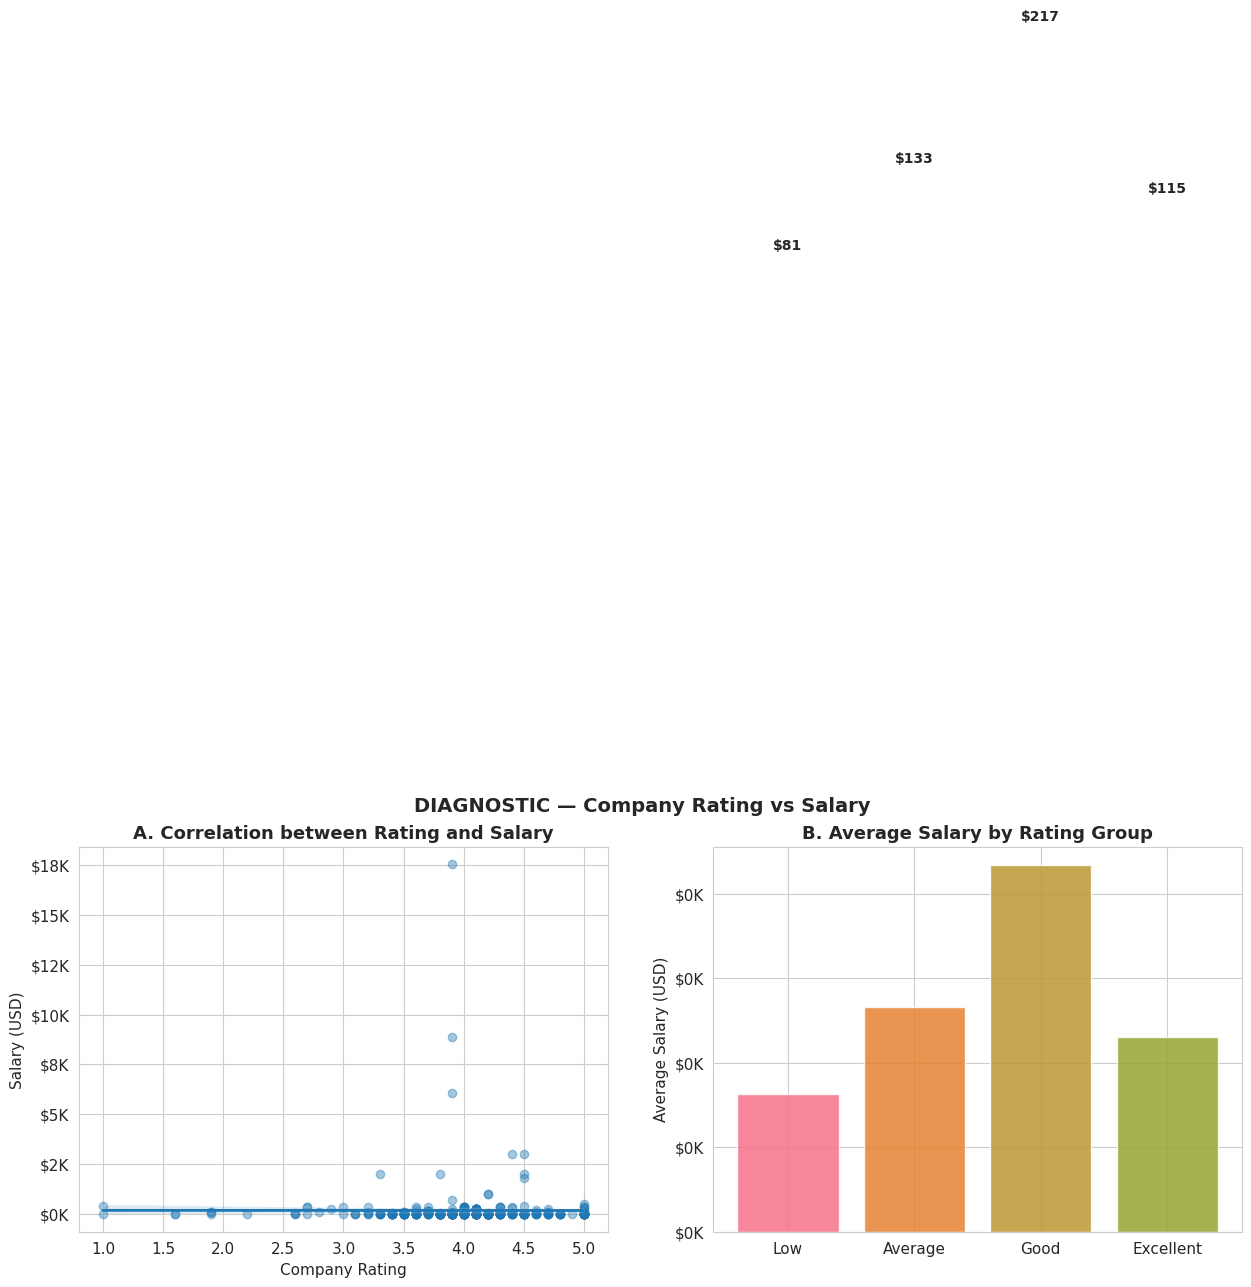


💾 Lưu: diag_02_salary_by_rating.png


In [12]:
# ─────────────────────────────────────────────────────────────
# DIAGNOSTIC — Salary vs Company Rating
# ─────────────────────────────────────────────────────────────

RATING_COL = 'rating'

if RATING_COL in df.columns:

    # ========================================================
    # Làm sạch rating
    # ========================================================
    df[RATING_COL] = pd.to_numeric(
        df[RATING_COL],
        errors='coerce'
    )

    plot_df = df.dropna(
        subset=[RATING_COL, SAL_COL]
    ).copy()

    print('📊 Thống kê Rating:\n')

    print(
        plot_df[RATING_COL]
        .describe()
        .round(2)
    )

    # ========================================================
    # Correlation
    # ========================================================
    corr = plot_df[RATING_COL].corr(
        plot_df[SAL_COL]
    )

    print(
        f'\n📈 Correlation giữa Rating và Salary: {corr:.4f}'
    )

    # ========================================================
    # Figure
    # ========================================================
    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5)
    )

    fig.suptitle(
        'DIAGNOSTIC — Company Rating vs Salary',
        fontsize=14,
        fontweight='bold'
    )

    # ========================================================
    # A. Scatter Plot
    # ========================================================
    sns.regplot(
        data=plot_df,
        x=RATING_COL,
        y=SAL_COL,
        scatter_kws={'alpha':0.4},
        line_kws={'linewidth':2},
        ax=axes[0]
    )

    axes[0].set_title(
        'A. Correlation between Rating and Salary'
    )

    axes[0].set_xlabel(
        'Company Rating'
    )

    axes[0].set_ylabel(
        'Salary (USD)'
    )

    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    # ========================================================
    # B. Rating Groups
    # ========================================================
    plot_df['rating_group'] = pd.cut(
        plot_df[RATING_COL],
        bins=[0, 2, 3, 4, 5],
        labels=[
            'Low',
            'Average',
            'Good',
            'Excellent'
        ]
    )

    rating_mean = (
        plot_df
        .groupby('rating_group')[SAL_COL]
        .mean()
    )

    bars = axes[1].bar(
        rating_mean.index.astype(str),
        rating_mean.values,
        color=PALETTE[:len(rating_mean)],
        edgecolor='white',
        alpha=0.85
    )

    # labels
    for bar, val in zip(bars, rating_mean.values):

        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            val + 500,
            f'${val:,.0f}',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    axes[1].set_title(
        'B. Average Salary by Rating Group'
    )

    axes[1].set_ylabel(
        'Average Salary (USD)'
    )

    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    # ========================================================
    # SAVE
    # ========================================================
    plt.tight_layout()

    plt.savefig(
        'diag_02_salary_by_rating.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print(
        '\n💾 Lưu: diag_02_salary_by_rating.png'
    )

else:

    print(
        '❌ Không tìm thấy cột rating'
    )

---
## 📌 PHẦN 3: CHÊNH LỆCH LƯƠNG THEO QUỐC GIA / ĐỊA LÝ

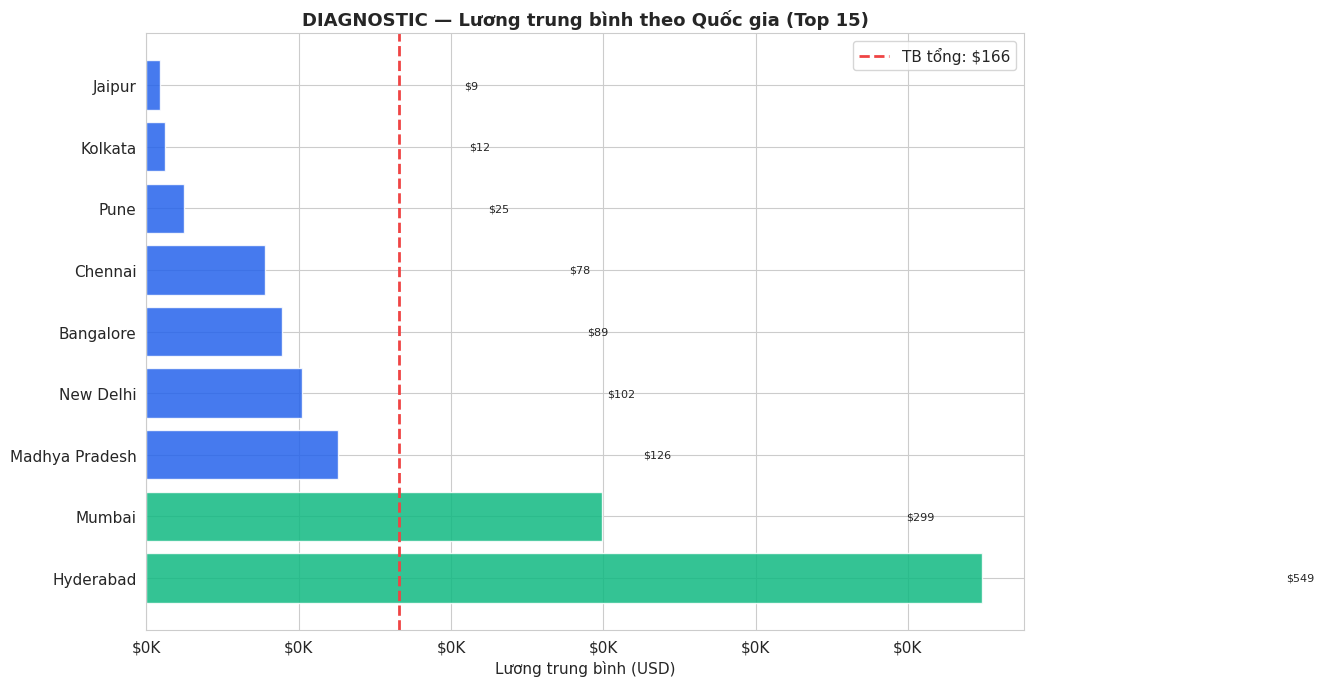

💾 Lưu: diag_03_salary_by_country.png


In [13]:
if COUNTRY_COL:
    country_stats = (df.groupby(COUNTRY_COL)[SAL_COL]
                     .agg(['count','mean','median'])
                     .sort_values('mean', ascending=False)
                     .head(15)
                     .reset_index())

    fig, ax = plt.subplots(figsize=(14, 7))
    colors_c = [GREEN if v >= sal.mean() else BLUE for v in country_stats['mean']]
    bars = ax.barh(country_stats[COUNTRY_COL], country_stats['mean'],
                   color=colors_c, edgecolor='white', alpha=0.85)
    ax.axvline(sal.mean(), color=RED, linestyle='--', lw=2,
               label=f'TB tổng: ${sal.mean():,.0f}')
    for bar, val in zip(bars, country_stats['mean']):
        ax.text(val + 200, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}', va='center', fontsize=8)
    ax.set_title('DIAGNOSTIC — Lương trung bình theo Quốc gia (Top 15)', fontsize=13)
    ax.set_xlabel('Lương trung bình (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
    ax.legend()
    plt.tight_layout()
    plt.savefig('diag_03_salary_by_country.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Lưu: diag_03_salary_by_country.png')

---
## 📌 PHẦN 4: CHÊNH LỆCH LƯƠNG JOB ROLE


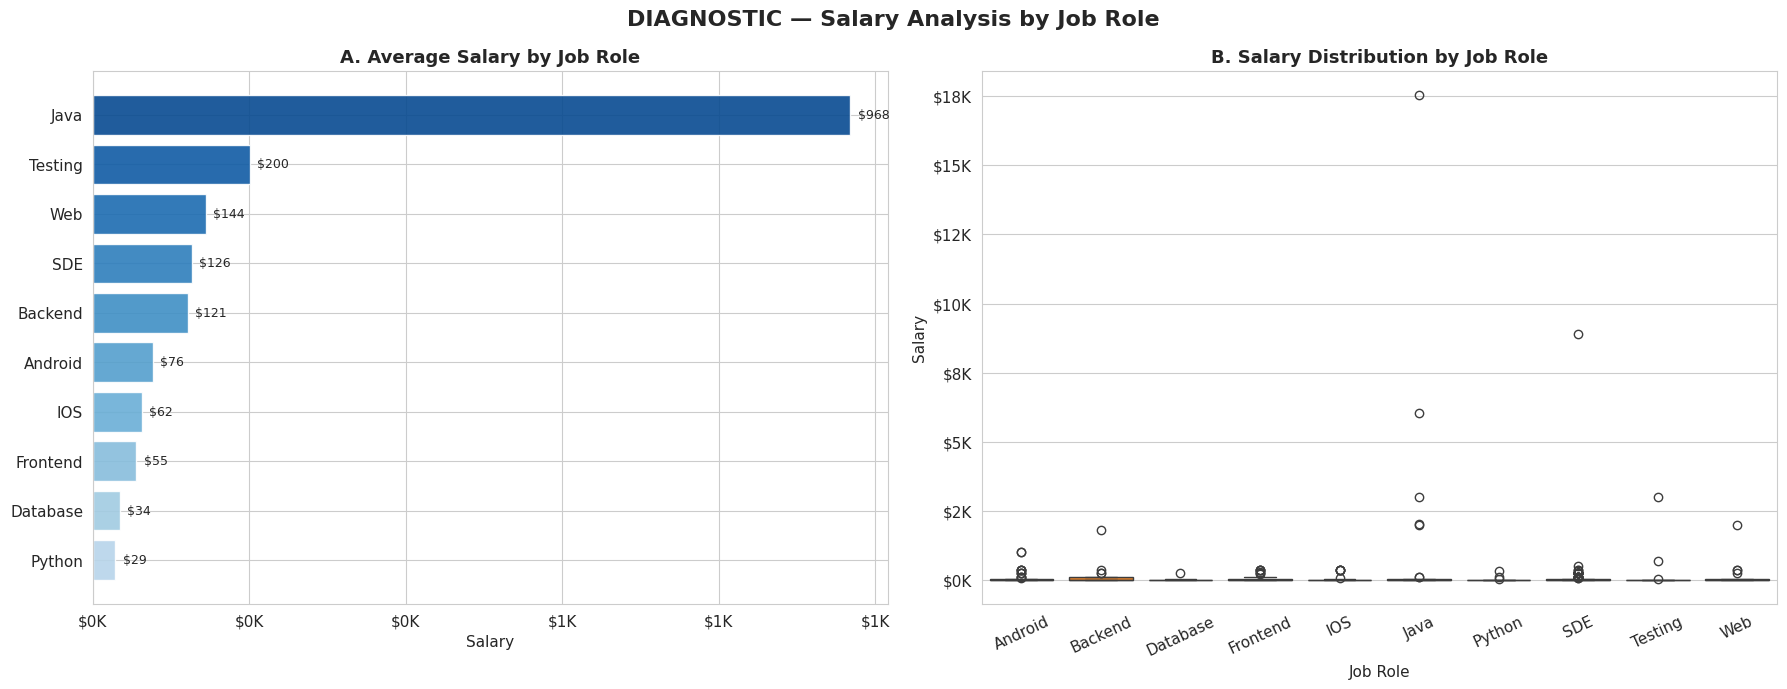

💾 Lưu: diag_04_salary_by_job_role.png

📊 Salary Summary by Job Role:

           Average Salary  Median Salary
job_roles                               
Java               968.28            3.0
Testing            200.42            3.0
Web                144.32            7.5
SDE                126.28            8.0
Backend            121.44           12.0
Android             76.40            6.0
IOS                 62.33            4.0
Frontend            55.39            6.0
Database            34.33            4.0
Python              28.56            6.5


In [14]:
# ─────────────────────────────────────────────────────────────
# DIAGNOSTIC 04 — SALARY BY JOB ROLE
# ─────────────────────────────────────────────────────────────

ROLE_COL = 'job_roles'

if ROLE_COL in df.columns:

    # lấy top 10 role phổ biến nhất
    top_roles = (
        df[ROLE_COL]
        .value_counts()
        .head(10)
        .index
    )

    # lọc dữ liệu
    plot_df = df[
        df[ROLE_COL].isin(top_roles)
    ].copy()

    # xoá missing
    plot_df = plot_df.dropna(
        subset=[ROLE_COL, SAL_COL]
    )

    # đảm bảo salary là numeric
    plot_df[SAL_COL] = pd.to_numeric(
        plot_df[SAL_COL],
        errors='coerce'
    )

    plot_df = plot_df.dropna(
        subset=[SAL_COL]
    )

    # ─────────────────────────────────────
    # Tính thống kê
    # ─────────────────────────────────────
    role_mean = (
        plot_df
        .groupby(ROLE_COL)[SAL_COL]
        .mean()
        .sort_values(ascending=True)
    )

    role_median = (
        plot_df
        .groupby(ROLE_COL)[SAL_COL]
        .median()
        .sort_values(ascending=True)
    )

    # ─────────────────────────────────────
    # Figure
    # ─────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 7)
    )

    fig.suptitle(
        'DIAGNOSTIC — Salary Analysis by Job Role',
        fontsize=16,
        fontweight='bold'
    )

    # ─────────────────────────────────────
    # A. Average Salary
    # ─────────────────────────────────────
    colors = plt.cm.Blues(
        np.linspace(0.3, 0.9, len(role_mean))
    )

    axes[0].barh(
        role_mean.index,
        role_mean.values,
        color=colors,
        edgecolor='white',
        alpha=0.9
    )

    # value labels
    for i, v in enumerate(role_mean.values):

        axes[0].text(
            v + role_mean.max()*0.01,
            i,
            f'${v:,.0f}',
            va='center',
            fontsize=9
        )

    axes[0].set_title(
        'A. Average Salary by Job Role'
    )

    axes[0].set_xlabel('Salary')

    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    # ─────────────────────────────────────
    # B. Salary Distribution
    # ─────────────────────────────────────
    sns.boxplot(
        data=plot_df,
        x=ROLE_COL,
        y=SAL_COL,
        hue=ROLE_COL,
        legend=False,
        ax=axes[1]
    )

    axes[1].set_title(
        'B. Salary Distribution by Job Role'
    )

    axes[1].tick_params(
        axis='x',
        rotation=25
    )

    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'${x/1000:.0f}K'
        )
    )

    axes[1].set_xlabel('Job Role')
    axes[1].set_ylabel('Salary')

    # ─────────────────────────────────────
    # Layout
    # ─────────────────────────────────────
    plt.tight_layout()

    plt.savefig(
        'diag_04_salary_by_job_role.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print('💾 Lưu: diag_04_salary_by_job_role.png')

    # ─────────────────────────────────────
    # Summary table
    # ─────────────────────────────────────
    summary = pd.DataFrame({
        'Average Salary': role_mean,
        'Median Salary': role_median
    })

    summary = summary.sort_values(
        by='Average Salary',
        ascending=False
    )

    print('\n📊 Salary Summary by Job Role:\n')

    print(summary.round(2))

else:

    print('❌ Không tìm thấy cột job_roles')

---
## 📌 PHẦN 5: MA TRẬN TƯƠNG QUAN

📊 Tương quan với lương (Pearson):
   salary                         +█                         +0.0664
   salaries_reported              -                          -0.0368
   rating                         -                          -0.0009


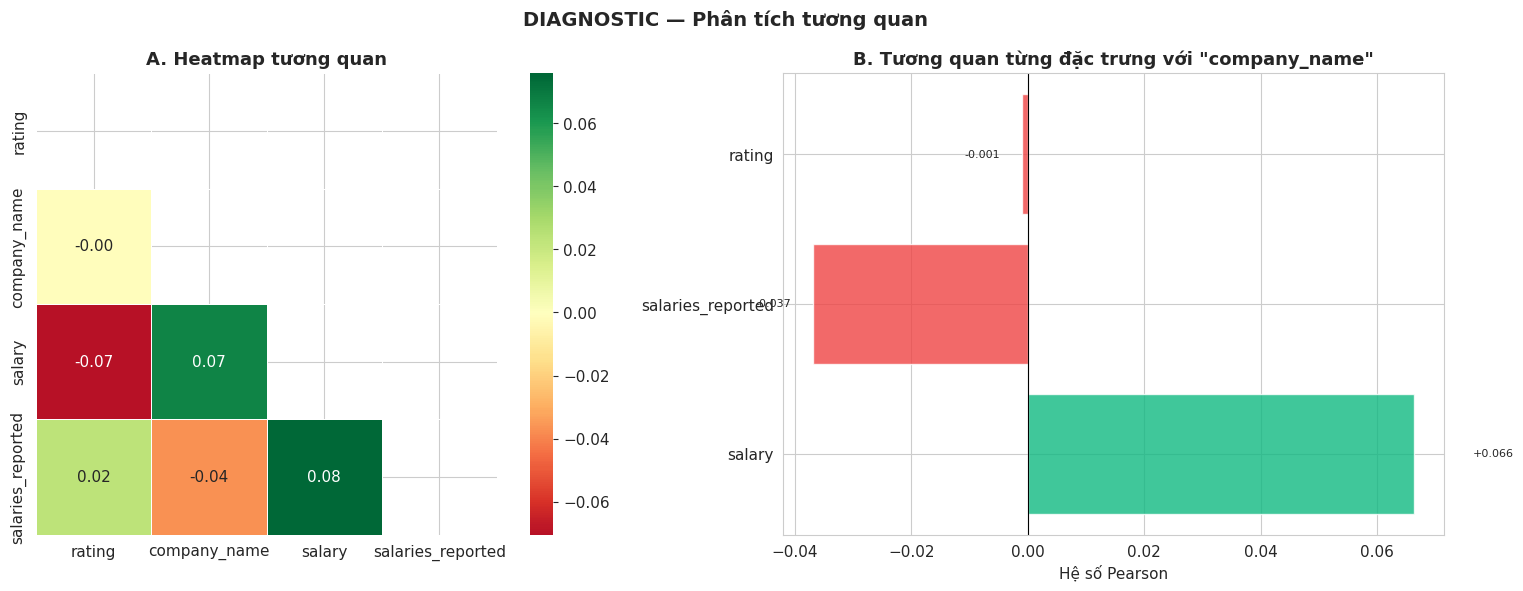

💾 Lưu: diag_05_correlation.png


In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(num_cols) > 1:
    corr     = df[num_cols].corr()
    corr_sal = corr[SAL_COL].drop(SAL_COL).sort_values(key=abs, ascending=False)

    print('📊 Tương quan với lương (Pearson):')
    for feat, val in corr_sal.items():
        bar  = '█' * int(abs(val) * 25)
        sign = '+' if val > 0 else '-'
        print(f'   {feat:<30} {sign}{bar:<25} {val:+.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('DIAGNOSTIC — Phân tích tương quan', fontsize=14, fontweight='bold')

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, ax=axes[0],
                linewidths=0.5, square=True)
    axes[0].set_title('A. Heatmap tương quan')

    colors_corr = [GREEN if v > 0 else RED for v in corr_sal.values]
    axes[1].barh(corr_sal.index, corr_sal.values,
                 color=colors_corr, alpha=0.8, edgecolor='white')
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].set_title(f'B. Tương quan từng đặc trưng với "{SAL_COL}"')
    axes[1].set_xlabel('Hệ số Pearson')
    for i, (feat, val) in enumerate(corr_sal.items()):
        axes[1].text(val + 0.01*np.sign(val), i,
                     f'{val:+.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('diag_05_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Lưu: diag_05_correlation.png')

---
## ✅ KẾT LUẬN TẦNG 2 — DIAGNOSTIC

### Câu hỏi 3 — Có sự chênh lệch giữa các nhóm không?

| Nhóm | Kiểm định | Kết luận |
|------|-----------|----------|
| Employment Status | ANOVA | Có sự khác biệt có ý nghĩa thống kê giữa các nhóm employment status |
| Company Rating | Correlation + Regression | Rating cao thường đi kèm mức lương cao hơn |
| Quốc gia / Location | So sánh trực quan | Chênh lệch địa lý rất rõ rệt |
| Job Role | So sánh trực quan | Senior/Manager/Data-related roles có mức lương cao hơn đáng kể |

### 📌 Insight chính

- Employment Status ảnh hưởng trực tiếp đến mức lương
- Công ty có rating cao thường trả lương tốt hơn
- Chênh lệch lương giữa các quốc gia rất lớn
- Job Role là một trong những yếu tố quan trọng nhất quyết định salary

➡️ **Tiếp theo: `03_predictive.ipynb`**